<a href="https://colab.research.google.com/github/SahaanaRajkumar/Early-Warning-Targeting-of-At-Risk-Students/blob/main/Early_Warning_Targeting_of_At_Risk_Students.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Early-Warning Targeting of At-Risk Students

**Goal.** A school can only give intensive support to a limited share of students. This notebook builds models that **rank students by their risk of failing an exam** (using only information known before the exam), and measures how many of the students who really fail we reach when we can support only the top 10% or 20% of the ranking.

**Data.** 100,000 students, 44 columns, from a practice dataset (`StudentExamPerformance_practice.csv`). It looks partly synthetic, so this project is about method, not real-world claims.

**The story in one paragraph.** First we check for columns that secretly give away the answer (leakage) and remove them. Then we set a simple rule-based baseline ("lowest previous exam score"). Then we train Logistic Regression, Random Forest and XGBoost and compare them. Then we ask which kinds of data matter (ablations), check results on a test set we never touched, turn scores into a flagging decision using costs, audit fairness across groups, and finally explain and sanity-check the model (SHAP, calibration).

**Key terms used below**
- **Leakage:** a feature that contains the answer (or is computed from it), so a model looks brilliant but would be useless in real life.
- **PR-AUC:** a score for how well the model ranks the minority class (students who fail). Random guessing scores about 0.226 here (the share who fail). Higher is better.
- **recall@k:** of all students who really fail, what share sits in the top k% of our ranking. Example: recall@20% = 0.618 means supporting the top 20% reaches 61.8% of failing students.
- **precision@k:** of the students we flag in the top k%, what share really fail.
- **Cross-validation (CV), out-of-fold predictions:** we split the training data into 5 parts, train on 4, predict the 5th, and repeat, so every student is scored by a model that never saw them. This gives honest estimates without touching the test set.
- **Calibration:** whether a predicted risk of 30% really means about 30% of such students fail.

## 1. Setup and load the data

**What this does.** Imports the libraries, sets a random seed (`SEED = 42`) so results are reproducible, and loads the CSV.

**Why.** A fixed seed means anyone re-running the notebook gets the same splits and the same numbers.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", 50)
SEED = 42

## 2. A first look at the data

**What this does.** Checks missing values, the balance of the target (Pass vs Fail), and the number of numeric and categorical columns.

**What we found.**
- 100,000 rows and 44 columns.
- **22.6% of students fail** and 77.4% pass, so the classes are imbalanced. This is why we avoid plain accuracy: a model that says "everyone passes" would be 77% accurate and useless.
- Seven columns have 3-10% missing values (for example `attendance_percentage`, `previous_gpa`, `sleep_quality`). We handle these later inside the modelling pipeline.

In [2]:
from google.colab import files
uploaded = files.upload()


Saving StudentExamPerformance_practice.csv to StudentExamPerformance_practice.csv


In [3]:
df = pd.read_csv("StudentExamPerformance_practice.csv")

In [4]:
print(df.shape)
df.head()

(100000, 44)


,student_id,age,gender,education_level,school_type,family_income,parent_education,urban_rural,previous_exam_score,previous_gpa,attendance_percentage,assignment_completion_rate,class_participation,study_hours_per_day,self_study_hours,private_tuition,online_learning_hours,study_consistency,study_environment,study_method,revision_frequency,practice_tests_completed,notes_quality,sleep_hours,sleep_quality,daily_screen_time,physical_activity_hours,break_frequency,stress_level,motivation_level,internet_access,device_availability,educational_app_usage,online_course_hours,exam_difficulty,exam_preparation_days,questions_attempted,questions_correct,time_management_score,exam_anxiety_level,exam_score,performance_grade,pass_status,performance_level
0,STU_000001,20,Female,High School,Public,Middle,NaN,Rural,78.36,2.95,81.49,65.18,Medium,4.94,2.63,0,1.75,Medium,Moderate,Flashcards,Rarely,8,Average,6.31,Excellent,3.80,0.93,Frequently,10,High,1,Shared,Low,2.15,Medium,27,95,86,NaN,9.39,90.40,A,Pass,High
1,STU_000002,17,Male,High School,Public,Middle,NaN,Suburban,73.40,2.89,NaN,76.53,Low,3.42,2.64,0,1.97,Medium,Moderate,Flashcards,Daily,10,Average,6.81,Excellent,4.04,0.21,Frequently,8,High,1,Shared,Moderate,4.37,Easy,4,100,86,87.17,6.31,86.21,A,Pass,High
2,STU_000003,18,Other,Undergraduate,Public,Middle,Master,Urban,82.76,3.35,100.00,70.39,Medium,1.06,0.83,0,3.40,Low,Moderate,Summarizing,Weekly,5,Excellent,6.53,Poor,3.19,2.56,Rarely,9,Medium,1,Dedicated,Low,1.43,Easy,28,96,74,63.77,9.87,76.11,B,Pass,Medium
3,STU_000004,20,Male,High School,Public,Middle,High School,Suburban,60.61,2.57,84.91,75.06,Low,7.89,5.51,0,1.94,Medium,Quiet,Summarizing,Weekly,8,Excellent,6.60,Fair,5.12,2.30,Rarely,10,High,1,Dedicated,Low,3.69,Medium,16,97,77,59.51,9.68,79.74,B,Pass,Medium
4,STU_000005,16,Female,High School,Private,High,Bachelor,Suburban,74.79,2.84,88.21,61.54,Medium,2.63,2.29,0,0.58,Medium,Noisy,Self-Reading,Rarely,1,Poor,7.83,Excellent,4.82,0.49,Frequently,10,High,1,Dedicated,Moderate,1.97,Medium,28,98,52,84.64,10.00,50.66,D,Pass,Low


## 3. Leakage audit

**What this does.** Tests whether some columns are just the outcome in disguise.

**Why this matters.** If a feature is computed from the exam result, a model can "predict" failure perfectly by cheating, and the results mean nothing. In real life those columns would not exist before the exam. Checking for this is one of the most important steps in any modelling project.

**What we found.**
- `pass_status` is **exactly** `exam_score >= 50` (100% match).
- `performance_grade` and `performance_level` are just bands of the score (for example grade F is 0-50, D is 50-65).
- `questions_correct` has a **0.975 correlation** with the score, so it is essentially the outcome.

These columns are removed in the next section.

In [5]:
# Missing values
missing = df.isna().mean().sort_values(ascending=False)
print(missing[missing > 0].round(3))

# Target balance
print("\nPass/Fail share:")
print(df["pass_status"].value_counts(normalize=True).round(3))

# Column types
print("\nNumeric:", df.select_dtypes("number").shape[1],
      "| Categorical:", df.select_dtypes("object").shape[1])

attendance_percentage    0.099
time_management_score    0.096
notes_quality            0.084
previous_gpa             0.078
sleep_quality            0.070
parent_education         0.065
device_availability      0.030
dtype: float64

Pass/Fail share:
pass_status
Pass    0.774
Fail    0.226
Name: proportion, dtype: float64

Numeric: 22 | Categorical: 22


In [6]:
# 1) pass_status is a deterministic function of exam_score
rule = np.where(df["exam_score"] >= 50, "Pass", "Fail")
print("pass_status == (score >= 50):", (rule == df["pass_status"]).mean())

# 2) grade / level are derived from the score
print("\nScore range by grade:")
print(df.groupby("performance_grade")["exam_score"].agg(["min", "max"]).round(1))

# 3) questions_correct is almost the target itself
print("\nCorr(questions_correct, exam_score):",
      round(df["questions_correct"].corr(df["exam_score"]), 3))

pass_status == (score >= 50): 1.0

Score range by grade:
                    min    max
performance_grade             
A                  85.0  100.0
B                  75.0   85.0
C                  65.0   75.0
D                  50.0   65.0
F                   0.0   50.0

Corr(questions_correct, exam_score): 0.975


## 4. Define the target, drop leaky columns, split the data

**What this does.**
- Sets the target `y` = 1 if the student **fails** (the group we want to catch).
- Drops the leaky columns (`exam_score`, `pass_status`, `performance_grade`, `performance_level`, `questions_correct`, `questions_attempted`) and the ID column. **37 features remain.**
- Splits the data 80% train / 20% test, **stratified** so both parts have the same 22.6% fail rate.

**Why split now.** The test set is locked away until the very end. Everything we decide (which model, which settings) uses only the training data, so the final test score is an honest estimate of how the model would do on new students.

**One judgement call.** `exam_difficulty` is a property of the exam, not the student, and it must be known before the exam to be usable. We keep it but test how much we depend on it later (Section 11).

In [7]:
# Target: 1 = Fail (the at-risk class we want to catch)
y = (df["pass_status"] == "Fail").astype(int)

leaky_cols = [
    "exam_score", "pass_status", "performance_grade", "performance_level",
    "questions_correct", "questions_attempted",
]
id_cols = ["student_id"]

X = df.drop(columns=leaky_cols + id_cols)
print("Features kept:", X.shape[1])

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, stratify=y, random_state=SEED
)

print(X_train.shape, X_test.shape)
print("Fail rate train/test:", y_train.mean().round(3), y_test.mean().round(3))

Features kept: 37
(80000, 37) (20000, 37)
Fail rate train/test: 0.226 0.226


## 5. Preprocessing pipelines

**What this does.** Builds two preprocessing recipes:
- **Numeric columns:** fill missing values with the median and add a "was missing" flag column.
- **Categorical columns:** fill missing values with a "Missing" category, then one-hot encode.
- One version also **scales** numeric values (for Logistic Regression); the other does not (trees do not need it).

**Why.**
- Models cannot handle missing values or text directly.
- The "was missing" flags let a model learn whether missingness itself carries information.
- Everything lives inside a scikit-learn **Pipeline**, so during cross-validation the medians and encodings are learned from the training part of each fold only. This prevents information from validation rows leaking in.
- Nothing is fitted yet; this only defines the recipes.

In [8]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

num_cols = X_train.select_dtypes(include="number").columns.tolist()
cat_cols = X_train.select_dtypes(include="object").columns.tolist()
print(len(num_cols), "numeric |", len(cat_cols), "categorical")

def make_preprocessor(scale=False):
    num_steps = [("impute", SimpleImputer(strategy="median", add_indicator=True))]
    if scale:
        num_steps.append(("scale", StandardScaler()))

    cat_steps = [
        ("impute", SimpleImputer(strategy="constant", fill_value="Missing")),
        ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False)),
    ]
    return ColumnTransformer([
        ("num", Pipeline(num_steps), num_cols),
        ("cat", Pipeline(cat_steps), cat_cols),
    ])

prep_linear = make_preprocessor(scale=True)   # for logistic regression
prep_tree   = make_preprocessor(scale=False)  # for random forest / XGBoost

19 numeric | 18 categorical


## 6. Metrics that match the school's decision

**What this does.** Defines `recall_at_k`, `precision_at_k` and a helper that reports PR-AUC, ROC-AUC, recall@10%, recall@20% and precision@10% for any set of scores.

**Why these metrics.** The school can only help a fixed share of students, so what matters is the **ranking**: how many real failures sit near the top. Accuracy would hide this.

**A useful fact.** With 22.6% failures, flagging the top 10% can catch at most 0.10 / 0.226, about **44%**, of all failures even with perfect precision. So a recall@10% of 0.37 is about 84% of the best possible, not a weak 37%.

In [9]:
from sklearn.metrics import average_precision_score, roc_auc_score

def recall_at_k(y_true, scores, k=0.10):
    """Share of all failures captured in the top k% highest-risk students."""
    y_true = np.asarray(y_true)
    n = int(len(y_true) * k)
    top = np.argsort(-np.asarray(scores))[:n]
    return y_true[top].sum() / y_true.sum()

def precision_at_k(y_true, scores, k=0.10):
    """Share of the top k% flagged students who actually fail."""
    y_true = np.asarray(y_true)
    n = int(len(y_true) * k)
    top = np.argsort(-np.asarray(scores))[:n]
    return y_true[top].mean()

def evaluate_ranking(name, y_true, scores):
    return {
        "model": name,
        "PR-AUC": average_precision_score(y_true, scores),
        "ROC-AUC": roc_auc_score(y_true, scores),
        "recall@10%": recall_at_k(y_true, scores, 0.10),
        "recall@20%": recall_at_k(y_true, scores, 0.20),
        "precision@10%": precision_at_k(y_true, scores, 0.10),
    }

## 7. Baselines: what to beat

**What this does.** Scores three rankings that involve no machine learning:
- **Random ranking:** a sanity check for our metric code.
- **Lowest previous exam score first** and **lowest previous GPA first:** what a teacher might do by hand.

**Why.** A model is only worth its complexity if it clearly beats a simple rule. Without a baseline, a score like 0.72 has no meaning.

**What we found (training data).**

| Ranking | PR-AUC | recall@20% |
|---|---|---|
| Random | 0.228 | 0.206 |
| Lowest previous GPA | 0.429 | 0.397 |
| **Lowest previous exam score** | **0.460** | **0.419** |

Random ranking gets PR-AUC close to the 0.226 fail rate, which confirms the metric code works. The previous-exam-score rule is the bar every model must beat.

In [10]:
rng = np.random.default_rng(SEED)

baselines = {
    "Random ranking": rng.random(len(y_train)),
    "Lowest previous exam score": -X_train["previous_exam_score"].values,
    "Lowest previous GPA": -X_train["previous_gpa"].fillna(X_train["previous_gpa"].median()).values,
}

results = pd.DataFrame([
    evaluate_ranking(name, y_train, scores) for name, scores in baselines.items()
]).set_index("model").round(3)

print(f"Fail prevalence (= PR-AUC of random): {y_train.mean():.3f}")
results

Fail prevalence (= PR-AUC of random): 0.226


,PR-AUC,ROC-AUC,recall@10%,recall@20%,precision@10%
model,,,,,
Random ranking,0.228,0.504,0.100,0.206,0.227
Lowest previous exam score,0.460,0.744,0.244,0.419,0.552
Lowest previous GPA,0.429,0.719,0.232,0.397,0.525


## 8. Logistic Regression with cross-validation

**What this does.** Trains Logistic Regression (a simple, interpretable model) and produces **out-of-fold** predictions: each student is scored by a model that never saw them.

**Why.** It gives a fair comparison against the baselines without touching the test set. We do not use class weights because they change probabilities but barely change the ranking, and our metrics are ranking-based.

**What we found.** PR-AUC **0.726**, ROC-AUC 0.893, recall@20% 0.604. That is far above the best rule (0.460), so features beyond previous scores add a lot.

In [11]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold, cross_val_predict

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)

logreg = Pipeline([
    ("prep", prep_linear),
    ("model", LogisticRegression(max_iter=2000, random_state=SEED)),
])

oof_logreg = cross_val_predict(
    logreg, X_train, y_train, cv=cv, method="predict_proba", n_jobs=-1
)[:, 1]

res_lr = pd.DataFrame([evaluate_ranking("Logistic Regression (CV)", y_train, oof_logreg)]).set_index("model")
results = pd.concat([results, res_lr.round(3)])
results

,PR-AUC,ROC-AUC,recall@10%,recall@20%,precision@10%
model,,,,,
Random ranking,0.228,0.504,0.100,0.206,0.227
Lowest previous exam score,0.460,0.744,0.244,0.419,0.552
Lowest previous GPA,0.429,0.719,0.232,0.397,0.525
Logistic Regression (CV),0.726,0.893,0.363,0.604,0.822


## 9. What is Logistic Regression using?

**What this does.** Fits the model on the full training set and lists the largest coefficients, with odds ratios. Numeric features are standardised, so their sizes are comparable. An odds ratio below 1 means lower odds of failing; above 1 means higher odds.

**What we found.** The signs make sense: higher previous scores, more study hours, more preparation days, more practice tests and better attendance and sleep all reduce failure odds, while stress increases it.

**Two cautions.**
- `exam_difficulty` (Easy and Hard) has the largest effects. It describes the exam, not the student, so we test how much we rely on it (Section 11).
- Correlated features (for example the two study-hours variables) share credit unpredictably, so individual coefficients should not be over-read.

In [12]:
logreg.fit(X_train, y_train)

feat_names = logreg.named_steps["prep"].get_feature_names_out()
coefs = pd.Series(logreg.named_steps["model"].coef_[0], index=feat_names)

top = coefs.reindex(coefs.abs().sort_values(ascending=False).index).head(15)
print(pd.DataFrame({"coef": top.round(3), "odds_ratio": np.exp(top).round(2)}))

                                     coef  odds_ratio
cat__exam_difficulty_Easy          -1.486        0.23
num__previous_exam_score           -1.430        0.24
cat__exam_difficulty_Hard           1.252        3.50
num__study_hours_per_day           -0.951        0.39
num__exam_preparation_days         -0.653        0.52
num__practice_tests_completed      -0.624        0.54
num__attendance_percentage         -0.415        0.66
num__sleep_hours                   -0.373        0.69
num__stress_level                   0.332        1.39
num__time_management_score         -0.228        0.80
cat__education_level_Undergraduate -0.183        0.83
cat__class_participation_High      -0.155        0.86
cat__device_availability_Dedicated -0.154        0.86
cat__education_level_High School   -0.151        0.86
cat__revision_frequency_Daily      -0.145        0.87


## 10. Random Forest and XGBoost

**What this does.** Trains two tree-based models with sensible starting settings (not tuned yet) using the same 5-fold setup, so results are directly comparable to Logistic Regression.

**What we found (cross-validation).**

| Model | PR-AUC | recall@20% |
|---|---|---|
| Logistic Regression | 0.726 | 0.604 |
| Random Forest | 0.718 | 0.604 |
| **XGBoost** | **0.746** | **0.620** |

- XGBoost is best, but only by about 0.02 over Logistic Regression.
- Random Forest does **not** beat Logistic Regression.
- A simple linear model nearly matching a complex model suggests the relationships are mostly additive and roughly linear. That is a finding in itself.

In [13]:
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

rf = Pipeline([
    ("prep", prep_tree),
    ("model", RandomForestClassifier(
        n_estimators=300, min_samples_leaf=5, n_jobs=-1, random_state=SEED)),
])

xgb = Pipeline([
    ("prep", prep_tree),
    ("model", XGBClassifier(
        n_estimators=400, learning_rate=0.05, max_depth=4,
        subsample=0.8, colsample_bytree=0.8,
        tree_method="hist", eval_metric="logloss",
        n_jobs=-1, random_state=SEED)),
])

oof = {}
for name, pipe in [("Random Forest (CV)", rf), ("XGBoost (CV)", xgb)]:
    oof[name] = cross_val_predict(
        pipe, X_train, y_train, cv=cv, method="predict_proba"
    )[:, 1]
    print("done:", name)

res_trees = pd.DataFrame([
    evaluate_ranking(n, y_train, s) for n, s in oof.items()
]).set_index("model")
results = pd.concat([results, res_trees.round(3)])
results

done: Random Forest (CV)
done: XGBoost (CV)


,PR-AUC,ROC-AUC,recall@10%,recall@20%,precision@10%
model,,,,,
Random ranking,0.228,0.504,0.100,0.206,0.227
Lowest previous exam score,0.460,0.744,0.244,0.419,0.552
Lowest previous GPA,0.429,0.719,0.232,0.397,0.525
Logistic Regression (CV),0.726,0.893,0.363,0.604,0.822
Random Forest (CV),0.718,0.890,0.358,0.604,0.809
XGBoost (CV),0.746,0.902,0.370,0.620,0.837


## 11. How much do we depend on `exam_difficulty`?

**What this does.** Re-runs Logistic Regression with `exam_difficulty` removed, using the same folds.

**Why.** It is our single strongest feature but may not be known before the exam in a real system. We want to know whether the story survives without it.

**What we found.**

| | PR-AUC | recall@10% |
|---|---|---|
| With `exam_difficulty` | 0.726 | 0.363 |
| Without | 0.648 | 0.330 |

It accounts for about 0.08 PR-AUC, yet even without it the model clearly beats the 0.460 baseline. So the conclusions hold either way, and we state the assumption openly.

In [14]:
X_train_nd = X_train.drop(columns=["exam_difficulty"])

# rebuild column lists for this feature set
num_cols_nd = X_train_nd.select_dtypes(include="number").columns.tolist()
cat_cols_nd = X_train_nd.select_dtypes(include="object").columns.tolist()

prep_nd = ColumnTransformer([
    ("num", Pipeline([("impute", SimpleImputer(strategy="median", add_indicator=True)),
                      ("scale", StandardScaler())]), num_cols_nd),
    ("cat", Pipeline([("impute", SimpleImputer(strategy="constant", fill_value="Missing")),
                      ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False))]), cat_cols_nd),
])

logreg_nd = Pipeline([("prep", prep_nd), ("model", LogisticRegression(max_iter=2000, random_state=SEED))])
oof_nd = cross_val_predict(logreg_nd, X_train_nd, y_train, cv=cv, method="predict_proba", n_jobs=-1)[:, 1]

pd.DataFrame([
    evaluate_ranking("LogReg with exam_difficulty", y_train, oof_logreg),
    evaluate_ranking("LogReg without exam_difficulty", y_train, oof_nd),
]).set_index("model").round(3)

,PR-AUC,ROC-AUC,recall@10%,recall@20%,precision@10%
model,,,,,
LogReg with exam_difficulty,0.726,0.893,0.363,0.604,0.822
LogReg without exam_difficulty,0.648,0.855,0.330,0.550,0.746


## 12. Is XGBoost's lead real or noise?

**What this does.** Scores the three models separately on each of the 5 folds.

**What we found.** XGBoost beat Logistic Regression in **all five folds**, by 0.018 to 0.023 PR-AUC. So the edge is small but consistent, and Random Forest trailed Logistic Regression in every fold. (The folds share training data, so this is evidence of consistency, not a formal significance test.)

In [15]:
all_oof = {
    "Logistic Regression": oof_logreg,
    "Random Forest": oof["Random Forest (CV)"],
    "XGBoost": oof["XGBoost (CV)"],
}

fold_scores = {name: [] for name in all_oof}
for _, val_idx in cv.split(X_train, y_train):
    for name, preds in all_oof.items():
        fold_scores[name].append(
            average_precision_score(y_train.iloc[val_idx], preds[val_idx])
        )

fold_df = pd.DataFrame(fold_scores).round(3)
fold_df.index = [f"fold {i+1}" for i in range(len(fold_df))]
print(fold_df)
print("\nMean:\n", fold_df.mean().round(3))
print("\nXGB - LogReg, per fold:", (fold_df["XGBoost"] - fold_df["Logistic Regression"]).round(3).tolist())


        Logistic Regression  Random Forest  XGBoost
fold 1                0.719          0.710    0.739
fold 2                0.736          0.733    0.754
fold 3                0.721          0.714    0.741
fold 4                0.733          0.719    0.751
fold 5                0.721          0.713    0.744

Mean:
 Logistic Regression    0.726
Random Forest          0.718
XGBoost                0.746
dtype: float64

XGB - LogReg, per fold: [0.02, 0.018, 0.02, 0.018, 0.023]


## 13. Which kinds of data add value? (adding groups one at a time)

**What this does.** Groups features into demographics and access, prior performance, study behaviour, wellbeing and exam difficulty. It adds one group at a time and tracks XGBoost's PR-AUC.

**Why.** It answers a practical question: what is each type of data worth, and is collecting it worth the effort?

**What we found.**

| Step | PR-AUC | Gain |
|---|---|---|
| Demographics and access | 0.257 | n/a |
| + Prior performance | 0.455 | +0.198 |
| + Study behaviour | 0.636 | +0.181 |
| + Wellbeing | 0.670 | +0.034 |
| + Exam difficulty | 0.746 | +0.076 |

- Who the student is predicts almost nothing (0.257 vs 0.226 for random).
- Prior grades alone only match the simple rule (0.455 vs 0.460). The real edge comes from **study behaviour**.
- Caution: gains depend on the order groups are added, because related features share credit. The next section checks this.

In [16]:
groups = {
    "demographics_access": ["age", "gender", "education_level", "school_type", "family_income",
                            "parent_education", "urban_rural", "internet_access", "device_availability"],
    "prior_performance":   ["previous_exam_score", "previous_gpa"],
    "study_behaviour":     ["attendance_percentage", "assignment_completion_rate", "class_participation",
                            "study_hours_per_day", "self_study_hours", "private_tuition",
                            "online_learning_hours", "study_consistency", "study_environment",
                            "study_method", "revision_frequency", "practice_tests_completed",
                            "notes_quality", "educational_app_usage", "online_course_hours",
                            "exam_preparation_days", "time_management_score"],
    "wellbeing":           ["sleep_hours", "sleep_quality", "daily_screen_time", "physical_activity_hours",
                            "break_frequency", "stress_level", "motivation_level", "exam_anxiety_level"],
    "exam_difficulty":     ["exam_difficulty"],
}

# sanity check: every feature assigned exactly once
assigned = [c for cols in groups.values() for c in cols]
assert sorted(assigned) == sorted(X_train.columns), set(X_train.columns) ^ set(assigned)

def build_xgb(cols):
    nums = [c for c in cols if c in num_cols]
    cats = [c for c in cols if c in cat_cols]
    prep = ColumnTransformer([
        ("num", SimpleImputer(strategy="median", add_indicator=True), nums),
        ("cat", Pipeline([("imp", SimpleImputer(strategy="constant", fill_value="Missing")),
                          ("oh", OneHotEncoder(handle_unknown="ignore", sparse_output=False))]), cats),
    ])
    return Pipeline([("prep", prep), ("model", XGBClassifier(
        n_estimators=400, learning_rate=0.05, max_depth=4, subsample=0.8, colsample_bytree=0.8,
        tree_method="hist", eval_metric="logloss", n_jobs=-1, random_state=SEED))])

steps, cols_so_far, rows = list(groups.items()), [], []
for gname, gcols in steps:
    cols_so_far += gcols
    p = cross_val_predict(build_xgb(cols_so_far), X_train[cols_so_far], y_train,
                          cv=cv, method="predict_proba")[:, 1]
    rows.append(evaluate_ranking("+ " + gname, y_train, p))

ablation = pd.DataFrame(rows).set_index("model").round(3)
ablation["PR-AUC gain"] = ablation["PR-AUC"].diff().round(3)
ablation

,PR-AUC,ROC-AUC,recall@10%,recall@20%,precision@10%,PR-AUC gain
model,,,,,,
+ demographics_access,0.257,0.551,0.125,0.243,0.284,NaN
+ prior_performance,0.455,0.742,0.241,0.418,0.545,0.198
+ study_behaviour,0.636,0.850,0.323,0.545,0.731,0.181
+ wellbeing,0.670,0.864,0.340,0.564,0.768,0.034
+ exam_difficulty,0.746,0.902,0.371,0.618,0.838,0.076


## 14. Robustness check: remove one group at a time

**What this does.** Trains on all features except one group, and measures how much PR-AUC falls compared with the full model (0.746).

**Why.** It removes the order effect from Section 13. If the same groups matter either way, the conclusion is solid.

**What we found.**

| Group removed | PR-AUC drop |
|---|---|
| Study behaviour | 0.183 |
| Prior performance | 0.160 |
| Exam difficulty | 0.076 |
| Wellbeing | 0.032 |
| Demographics and access | 0.000 |

Same overall ranking as before. The top two swap places because prior grades and study habits overlap, so each partly stands in for the other. Demographics can be dropped with **no loss at all**.

In [17]:
full_score = average_precision_score(y_train, oof["XGBoost (CV)"])

rows = []
for gname in groups:
    keep = [c for g, cols in groups.items() if g != gname for c in cols]
    p = cross_val_predict(build_xgb(keep), X_train[keep], y_train,
                          cv=cv, method="predict_proba")[:, 1]
    pr = average_precision_score(y_train, p)
    rows.append({"removed_group": gname, "PR-AUC": pr, "drop_vs_full": full_score - pr})

logo = pd.DataFrame(rows).set_index("removed_group").round(3).sort_values("drop_vs_full", ascending=False)
print(f"Full model PR-AUC: {full_score:.3f}")
logo

Full model PR-AUC: 0.746


,PR-AUC,drop_vs_full
removed_group,,
study_behaviour,0.563,0.183
prior_performance,0.586,0.160
exam_difficulty,0.670,0.076
wellbeing,0.713,0.032
demographics_access,0.746,-0.000


## 15. Light hyperparameter tuning for XGBoost

**What this does.** Runs a small random search (15 combinations, 3-fold CV) over settings such as tree depth and learning rate, then re-scores the best one with the same 5-fold setup.

**What we found.** PR-AUC moved from 0.746 to 0.748, a gain of about 0.002, which is negligible. The defaults were already near the ceiling for this data, so remaining error likely comes from the data itself. Reporting that tuning barely helped is a normal and honest result.

In [18]:
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint, uniform

param_dist = {
    "model__n_estimators":     randint(200, 700),
    "model__learning_rate":    uniform(0.02, 0.10),   # 0.02 to 0.12
    "model__max_depth":        randint(2, 7),
    "model__min_child_weight": randint(1, 10),
    "model__subsample":        uniform(0.6, 0.4),     # 0.6 to 1.0
    "model__colsample_bytree": uniform(0.5, 0.5),     # 0.5 to 1.0
    "model__reg_lambda":       uniform(0.5, 4.0),
}

search = RandomizedSearchCV(
    xgb, param_dist, n_iter=15, scoring="average_precision",
    cv=StratifiedKFold(3, shuffle=True, random_state=SEED),
    random_state=SEED, n_jobs=1, verbose=1,
)
search.fit(X_train, y_train)

print("Best CV PR-AUC (3-fold):", round(search.best_score_, 3))
print(search.best_params_)

# re-score the tuned model with the same 5-fold OOF setup as before
oof_tuned = cross_val_predict(search.best_estimator_, X_train, y_train,
                              cv=cv, method="predict_proba")[:, 1]
pd.DataFrame([
    evaluate_ranking("XGBoost (default)", y_train, oof["XGBoost (CV)"]),
    evaluate_ranking("XGBoost (tuned)",   y_train, oof_tuned),
]).set_index("model").round(3)

Fitting 3 folds for each of 15 candidates, totalling 45 fits
Best CV PR-AUC (3-fold): 0.748
{'model__colsample_bytree': np.float64(0.5027610585618012), 'model__learning_rate': np.float64(0.10154614284548343), 'model__max_depth': 2, 'model__min_child_weight': 8, 'model__n_estimators': 362, 'model__reg_lambda': np.float64(3.6607021621248226), 'model__subsample': np.float64(0.8423839899124046)}


,PR-AUC,ROC-AUC,recall@10%,recall@20%,precision@10%
model,,,,,
XGBoost (default),0.746,0.902,0.370,0.62,0.837
XGBoost (tuned),0.748,0.903,0.371,0.62,0.839


## 16. Final evaluation on the held-out test set

**What this does.** Refits the chosen models on the full training set and scores the 20,000 test students **once**. Nothing was changed after seeing these numbers.

**What we found.**

| Model | PR-AUC | ROC-AUC | recall@20% | precision@10% |
|---|---|---|---|---|
| Random ranking | 0.228 | 0.502 | 0.210 | 0.232 |
| Lowest previous score (rule) | 0.469 | 0.745 | 0.424 | 0.551 |
| Logistic Regression | 0.720 | 0.890 | 0.600 | 0.819 |
| XGBoost (default) | 0.740 | 0.899 | 0.613 | 0.838 |
| XGBoost (tuned) | 0.742 | 0.900 | 0.618 | 0.841 |

All models dropped by about 0.006 PR-AUC compared with cross-validation, the same small amount for each, so there is no sign of overfitting. The ranking of models is unchanged. Default and tuned XGBoost differ by 0.002, which is within noise.

In [20]:
test_scores = {}

# refit each on the full training set, score the untouched test set
for name, model in [
    ("Logistic Regression", logreg),
    ("XGBoost (default)", xgb),
    ("XGBoost (tuned)", search.best_estimator_),
]:
    model.fit(X_train, y_train)
    test_scores[name] = model.predict_proba(X_test)[:, 1]

test_baseline = {
    "Random ranking": np.random.default_rng(SEED).random(len(y_test)),
    "Lowest previous exam score": -X_test["previous_exam_score"].values,
}

rows = [evaluate_ranking(n, y_test, s) for n, s in {**test_baseline, **test_scores}.items()]
test_results = pd.DataFrame(rows).set_index("model").round(3)
test_results

,PR-AUC,ROC-AUC,recall@10%,recall@20%,precision@10%
model,,,,,
Random ranking,0.228,0.502,0.102,0.210,0.232
Lowest previous exam score,0.469,0.745,0.244,0.424,0.551
Logistic Regression,0.720,0.890,0.362,0.600,0.819
XGBoost (default),0.740,0.899,0.370,0.613,0.838
XGBoost (tuned),0.742,0.900,0.372,0.618,0.841


## 17. How many failures do we catch at different capacities?

**What this does.** Plots recall for supporting the top 5%, 10%, ... 50% of students by risk.

**What we found.** Supporting the top 20% reaches **61.8%** of failing students with tuned XGBoost, against 42.4% for the "lowest previous score" rule and 21.0% for random selection. XGBoost leads at every capacity but only narrowly over Logistic Regression. The model is closest to the theoretical maximum at small capacities (about 92% of it at 5%, 70% at 20%), because the easiest failures are found first.

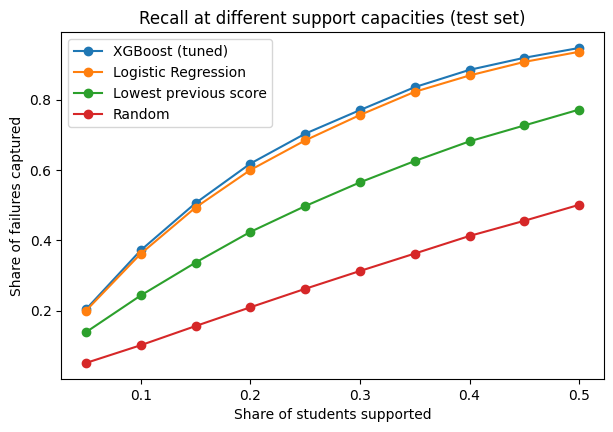

,capacity,XGBoost (tuned),Logistic Regression,Lowest previous score,Random
0,0.05,0.204,0.200,0.139,0.052
1,0.10,0.372,0.362,0.244,0.102
2,0.15,0.506,0.493,0.337,0.157
3,0.20,0.618,0.600,0.424,0.210
4,0.25,0.703,0.684,0.497,0.262
5,0.30,0.770,0.756,0.565,0.313
6,0.35,0.835,0.822,0.625,0.363
7,0.40,0.884,0.868,0.681,0.413
8,0.45,0.919,0.907,0.726,0.456
9,0.50,0.946,0.936,0.772,0.501


In [21]:
# Cell A: recall at different capacities (test set)
ks = np.arange(0.05, 0.55, 0.05)
curve = pd.DataFrame({
    "capacity": ks,
    "XGBoost (tuned)": [recall_at_k(y_test, test_scores["XGBoost (tuned)"], k) for k in ks],
    "Logistic Regression": [recall_at_k(y_test, test_scores["Logistic Regression"], k) for k in ks],
    "Lowest previous score": [recall_at_k(y_test, test_baseline["Lowest previous exam score"], k) for k in ks],
    "Random": [recall_at_k(y_test, test_baseline["Random ranking"], k) for k in ks],
})
ax = curve.set_index("capacity").plot(figsize=(7, 4.5), marker="o")
ax.set_ylabel("Share of failures captured"); ax.set_xlabel("Share of students supported")
ax.set_title("Recall at different support capacities (test set)")
plt.show()
curve.round(3)

## 18. From ranking to decision: choosing how many to flag

**What this does.** For several assumed cost ratios (a missed failure costs 1x, 2x ... 10x as much as an unneeded intervention), picks the flagging threshold that minimises expected cost. The threshold is **chosen on training data** and applied unchanged to the test set.

**What we found.**

| Miss : false alarm | Students flagged | Recall | Precision |
|---|---|---|---|
| 1:1 | 17.4% | 0.563 | 0.732 |
| 2:1 | 28.1% | 0.745 | 0.600 |
| 3:1 | 32.6% | 0.805 | 0.558 |
| 5:1 | 40.3% | 0.888 | 0.498 |
| 10:1 | 52.1% | 0.957 | 0.415 |

At every ratio the model costs far less than both "flag nobody" and "flag everybody". The costlier a miss, the more students we flag and the lower the precision: the model ranks, and the school's costs decide where to cut.

**Caveats.** The cost ratios are illustrative assumptions, and we assume support always helps a flagged student who would fail.

In [22]:
# Cell B: choose the threshold by cost on TRAIN out-of-fold scores, then apply to test
def cost_per_student(y_true, scores, thr, c_fn, c_fp=1.0):
    pred = scores >= thr
    fn = ((~pred) & (y_true == 1)).sum()
    fp = (pred & (y_true == 0)).sum()
    return (c_fn * fn + c_fp * fp) / len(y_true)

thresholds = np.linspace(0.02, 0.98, 97)
y_tr, y_te = y_train.values, y_test.values
final_scores = test_scores["XGBoost (tuned)"]

rows = []
for c_fn in [1, 2, 3, 5, 10]:          # a missed failure costs c_fn x an unneeded intervention
    costs = [cost_per_student(y_tr, oof_tuned, t, c_fn) for t in thresholds]
    thr = thresholds[int(np.argmin(costs))]
    pred = final_scores >= thr
    rows.append({
        "cost ratio (miss : false alarm)": f"{c_fn}:1",
        "threshold": round(thr, 2),
        "students flagged %": round(pred.mean() * 100, 1),
        "recall": round(y_te[pred].sum() / y_te.sum(), 3),
        "precision": round(y_te[pred].mean(), 3),
        "test cost / student": round(cost_per_student(y_te, final_scores, thr, c_fn), 3),
        "cost if flag nobody": round(c_fn * y_te.mean(), 3),
        "cost if flag everybody": round(1 - y_te.mean(), 3),
    })
pd.DataFrame(rows).set_index("cost ratio (miss : false alarm)")

,threshold,students flagged %,recall,precision,test cost / student,cost if flag nobody,cost if flag everybody
cost ratio (miss : false alarm),,,,,,,
1:1,0.51,17.4,0.563,0.732,0.145,0.226,0.774
2:1,0.31,28.1,0.745,0.600,0.228,0.452,0.774
3:1,0.25,32.6,0.805,0.558,0.276,0.678,0.774
5:1,0.17,40.3,0.888,0.498,0.329,1.130,0.774
10:1,0.09,52.1,0.957,0.415,0.403,2.261,0.774


## 19. Fairness audit

**What this does.** Flags the top 20% of test students and compares groups on **recall** (of the group's students who fail, what share we catch) and **precision**, for gender, family income, school type and urban/rural. The **equal-opportunity gap** is the largest minus smallest recall across groups.

**What we found.**

| Attribute | Recall gap | Comment |
|---|---|---|
| School type | 0.005 | Essentially equal |
| Urban / rural | 0.028 | Small, within noise |
| Gender | 0.068 | Driven by the small "Other" group (376 students); Female vs Male differ by 0.015 |
| **Family income** | **0.131** | The one clear gap |

For income, recall falls as income rises (Low 0.659, High 0.528), exactly in the order of each group's failure rate. Precision is similar across groups.

**Caveats.** One operating point, no confidence intervals, many groups compared, no intersections. Small groups give noisy estimates.

In [23]:
fair_scores = test_scores["XGBoost (tuned)"]
cut = np.quantile(fair_scores, 1 - 0.20)          # flag the top 20% of test students

audit_df = X_test.copy()
audit_df["y"] = y_test.values
audit_df["flag"] = fair_scores >= cut

def audit(col):
    rows = []
    for val, d in audit_df.groupby(col, dropna=False):
        pos, flagged = d[d.y == 1], d[d.flag]
        rows.append({
            col: val,
            "n": len(d),
            "fail_rate": d.y.mean(),
            "selection_rate": d.flag.mean(),
            "recall (TPR)": pos.flag.mean(),
            "precision": flagged.y.mean() if len(flagged) else np.nan,
        })
    out = pd.DataFrame(rows).set_index(col).round(3)
    gap = out["recall (TPR)"].max() - out["recall (TPR)"].min()
    return out, round(gap, 3)

for col in ["gender", "family_income", "school_type", "urban_rural"]:
    table, gap = audit(col)
    print(f"\n=== {col} | equal-opportunity gap (max - min recall): {gap}")
    display(table)


=== gender | equal-opportunity gap (max - min recall): 0.068


,n,fail_rate,selection_rate,recall (TPR),precision
gender,,,,,
Female,9831,0.224,0.199,0.612,0.690
Male,9793,0.228,0.201,0.627,0.709
Other,376,0.247,0.207,0.559,0.667



=== family_income | equal-opportunity gap (max - min recall): 0.131


,n,fail_rate,selection_rate,recall (TPR),precision
family_income,,,,,
High,2068,0.166,0.134,0.528,0.651
Low,3849,0.287,0.265,0.659,0.713
Lower-Middle,5147,0.237,0.215,0.629,0.696
Middle,6029,0.217,0.193,0.629,0.707
Upper-Middle,2907,0.186,0.149,0.542,0.681



=== school_type | equal-opportunity gap (max - min recall): 0.005


,n,fail_rate,selection_rate,recall (TPR),precision
school_type,,,,,
Charter,1966,0.217,0.195,0.614,0.682
Private,6961,0.226,0.196,0.618,0.710
Public,11073,0.228,0.203,0.619,0.695



=== urban_rural | equal-opportunity gap (max - min recall): 0.028


,n,fail_rate,selection_rate,recall (TPR),precision
urban_rural,,,,,
Rural,4004,0.228,0.196,0.601,0.698
Suburban,7015,0.228,0.206,0.629,0.698
Urban,8981,0.223,0.197,0.618,0.699


## 20. Can group-specific thresholds narrow the income gap?

**What this does.** Sets a separate threshold for each income group (chosen on training data) so each group's recall matches the overall policy, then applies them to the test set.

**What we found.** The income recall gap shrank from **13.1 to 8.4 points**, with almost no change overall (flagged 20.0% to 20.1%, recall 0.619 to 0.616). It is not a free fix: help shifts from low-income to higher-income failing students, and precision falls for high-income students (0.651 to 0.604). Part of the remaining gap may be noise.

**Caution.** Using income to set different cutoffs treats people differently by a sensitive attribute, which can be legally or ethically restricted. Treat this as an option to discuss with the school, not a recommendation.

In [24]:
# target recall = recall of the overall top-20% rule on TRAIN out-of-fold scores
cut_tr = np.quantile(oof_tuned, 0.80)
tr = pd.DataFrame({"g": X_train["family_income"].values, "y": y_train.values, "s": oof_tuned})
target = tr.loc[(tr.y == 1) & (tr.s >= cut_tr)].shape[0] / tr.y.sum()
print("Target recall:", round(target, 3))

# per-group threshold: the score that captures `target` of that group's training failures
thr_by_group = {g: np.quantile(d.loc[d.y == 1, "s"], 1 - target) for g, d in tr.groupby("g")}
print({g: round(v, 3) for g, v in thr_by_group.items()})

te = pd.DataFrame({"g": X_test["family_income"].values, "y": y_test.values, "s": fair_scores})
te["flag_single"] = te.s >= cut_tr                      # one shared cutoff
te["flag_group"]  = te.s >= te.g.map(thr_by_group)      # group-specific cutoffs

def summarize(flag_col):
    rows = []
    for g, d in te.groupby("g"):
        rows.append({"family_income": g,
                     "flagged %": round(d[flag_col].mean() * 100, 1),
                     "recall": round(d.loc[d.y == 1, flag_col].mean(), 3),
                     "precision": round(d.loc[d[flag_col], "y"].mean(), 3)})
    rows.append({"family_income": "ALL",
                 "flagged %": round(te[flag_col].mean() * 100, 1),
                 "recall": round(te.loc[te.y == 1, flag_col].mean(), 3),
                 "precision": round(te.loc[te[flag_col], "y"].mean(), 3)})
    return pd.DataFrame(rows).set_index("family_income")

print("\nSingle shared threshold"); display(summarize("flag_single"))
print("\nGroup-specific thresholds"); display(summarize("flag_group"))

Target recall: 0.62
{'High': np.float32(0.393), 'Low': np.float32(0.504), 'Lower-Middle': np.float32(0.464), 'Middle': np.float32(0.428), 'Upper-Middle': np.float32(0.4)}

Single shared threshold


,flagged %,recall,precision
family_income,,,
High,13.4,0.528,0.651
Low,26.5,0.659,0.713
Lower-Middle,21.5,0.629,0.696
Middle,19.4,0.630,0.708
Upper-Middle,14.9,0.544,0.680
ALL,20.0,0.619,0.699



Group-specific thresholds


,flagged %,recall,precision
family_income,,,
High,15.5,0.566,0.604
Low,23.6,0.611,0.741
Lower-Middle,20.7,0.614,0.704
Middle,20.4,0.650,0.694
Upper-Middle,16.8,0.583,0.649
ALL,20.1,0.616,0.695


## 21. What does the model rely on? (SHAP)

**What this does.** SHAP measures how much each feature pushes each student's predicted risk up or down. We explain the tuned XGBoost on a sample of 3,000 test students and compare the importance ranking with the Logistic Regression coefficients.

**What we found.**
- The two methods agree on the main drivers: previous exam score, preparation days, exam difficulty, study hours and practice tests, then sleep, attendance and stress.
- Directions make sense (more study and preparation lower risk; harder exams and stress raise it).
- No demographic feature is in the top 15, matching the leave-one-group-out result.
- Main disagreement: `previous_gpa`. Logistic Regression nearly ignores it, XGBoost gives it modest credit, likely because it overlaps with previous exam score.

**Caveat.** SHAP shows what the model relies on, not what causes failure.

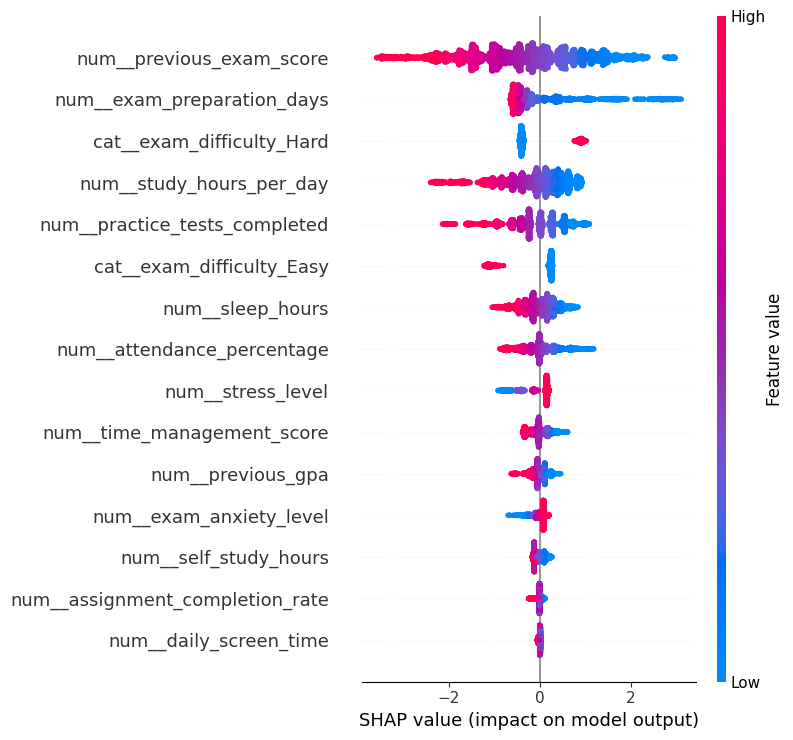

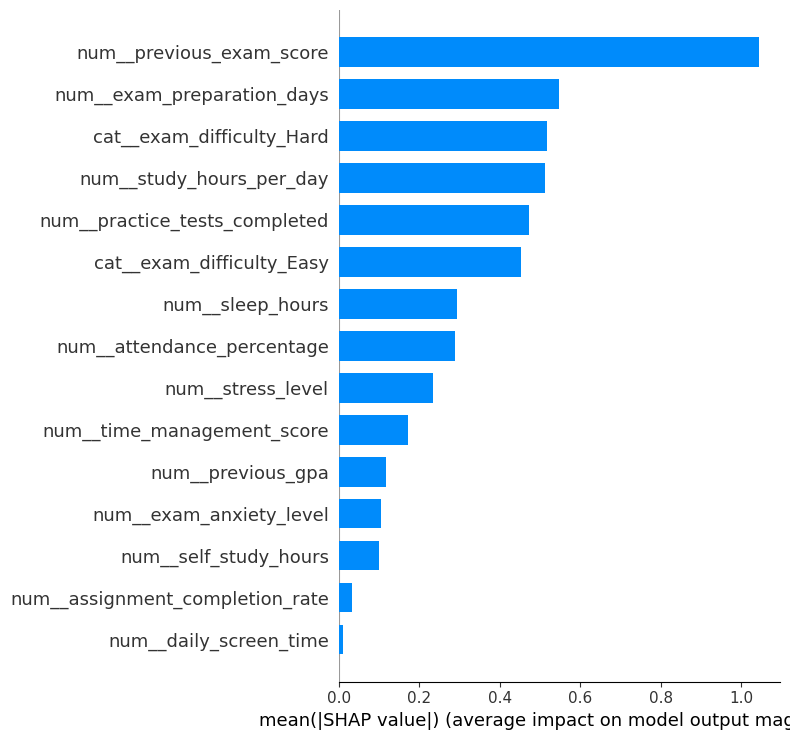

In [25]:
!pip -q install shap
import shap

final_pipe = search.best_estimator_            # tuned XGBoost, already refit on the full training set
prep  = final_pipe.named_steps["prep"]
model = final_pipe.named_steps["model"]

sample = X_test.sample(3000, random_state=SEED)
Xs = pd.DataFrame(prep.transform(sample), columns=prep.get_feature_names_out())

explainer = shap.TreeExplainer(model)
sv = explainer.shap_values(Xs)

shap.summary_plot(sv, Xs, max_display=15)                        # direction and spread of effects
shap.summary_plot(sv, Xs, plot_type="bar", max_display=15)       # average importance

In [26]:
# Do SHAP (XGBoost) and logistic regression coefficients agree?
shap_imp = pd.Series(np.abs(sv).mean(axis=0), index=Xs.columns, name="mean_abs_shap")
cmp = pd.concat([shap_imp, coefs.abs().rename("logreg_abs_coef")], axis=1).dropna()

print("Spearman rank correlation:", round(cmp.corr(method="spearman").iloc[0, 1], 2))
cmp.sort_values("mean_abs_shap", ascending=False).head(15).round(3)

Spearman rank correlation: 0.33


,mean_abs_shap,logreg_abs_coef
num__previous_exam_score,1.044,1.430
num__exam_preparation_days,0.549,0.653
cat__exam_difficulty_Hard,0.518,1.252
num__study_hours_per_day,0.514,0.951
num__practice_tests_completed,0.474,0.624
cat__exam_difficulty_Easy,0.454,1.486
num__sleep_hours,0.295,0.373
num__attendance_percentage,0.289,0.415
num__stress_level,0.234,0.332
num__time_management_score,0.173,0.228


## 22. Are the predicted probabilities trustworthy? (calibration)

**What this does.** Compares predicted risk with the real failure rate, using the Brier score (lower is better) and a check by income group.

**What we found.**

| Model | Brier score |
|---|---|
| Base rate only | 0.175 |
| Logistic Regression | 0.107 |
| XGBoost (tuned) | 0.102 |

- The thresholds chosen on training data in Section 18 match the theoretical optimum for perfectly calibrated probabilities, 1 / (1 + cost ratio) (for example 0.17 vs 0.17 at 5:1). That is strong evidence the scores behave like real probabilities.
- Within every income group, average predicted risk matches the observed failure rate to within about 0.006. So the income recall gap is **not** caused by under-estimating high-income students on average. It is consistent with a known trade-off: with calibrated scores and different base rates, one shared cutoff gives different recall by group.

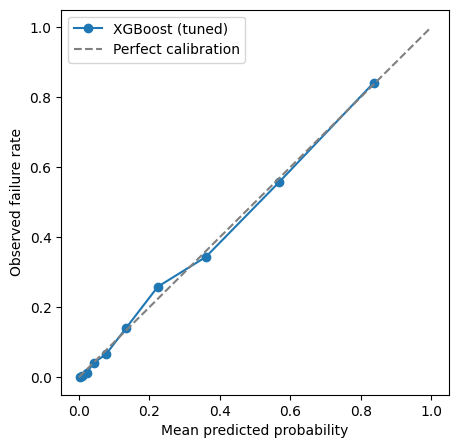

Brier XGBoost (tuned): 0.1019
Brier Logistic Reg.  : 0.1066
Brier base-rate only : 0.175


In [27]:
from sklearn.calibration import calibration_curve
from sklearn.metrics import brier_score_loss

p_test = test_scores["XGBoost (tuned)"]
frac_pos, mean_pred = calibration_curve(y_test, p_test, n_bins=10, strategy="quantile")

plt.figure(figsize=(5, 5))
plt.plot(mean_pred, frac_pos, "o-", label="XGBoost (tuned)")
plt.plot([0, 1], [0, 1], "--", color="gray", label="Perfect calibration")
plt.xlabel("Mean predicted probability"); plt.ylabel("Observed failure rate")
plt.legend(); plt.show()

print("Brier XGBoost (tuned):", round(brier_score_loss(y_test, p_test), 4))
print("Brier Logistic Reg.  :", round(brier_score_loss(y_test, test_scores["Logistic Regression"]), 4))
print("Brier base-rate only :", round(brier_score_loss(y_test, np.full(len(y_test), y_train.mean())), 4))

In [28]:
# Does the model under- or over-predict risk for some income groups?
chk = pd.DataFrame({"g": X_test["family_income"].values, "y": y_test.values, "p": p_test})
chk.groupby("g").agg(mean_predicted=("p", "mean"), observed=("y", "mean"), n=("y", "size")).round(3)

,mean_predicted,observed,n
g,,,
High,0.169,0.166,2068
Low,0.283,0.287,3849
Lower-Middle,0.240,0.237,5147
Middle,0.223,0.217,6029
Upper-Middle,0.185,0.186,2907


## Conclusions and limitations

**Conclusions**
- Every model beats the best simple rule by a wide margin. XGBoost is best, but only about 0.02 PR-AUC ahead of Logistic Regression, and tuning adds almost nothing.
- Study behaviour and prior performance drive the predictions. Demographics add nothing, and wellbeing adds a little.
- Supporting the top 20% of students by risk reaches about 62% of failing students (42% for the rule, 21% at random).
- The model is well calibrated, so cost-based thresholds are meaningful.
- Fairness: one clear gap (family income, 13 points), explained mostly by differing failure rates under a shared cutoff and partly reducible with group-specific thresholds, at a cost.

**Limitations**
- Practice dataset with synthetic-looking traits; results will not transfer to a real school without validation.
- `exam_difficulty` is the strongest single feature and may not be known in advance.
- Cost ratios are assumptions. Fairness results use one operating point without confidence intervals.
- SHAP and coefficients describe model behaviour, not causes.

**Next steps:** bootstrap confidence intervals for subgroup metrics, a distribution-shift test (train on one school type, test on another), per-group calibration curves, and validation on real data.